# Working with Rasterio

## Read the Raster

In [1]:
# Import Rasterio for raster data access and metadata handling
import rasterio
# Bring in Rasterio's plotting helper utilities
import rasterio.plot
# GeoPandas lets us load and reproject vector data like GeoJSON
import geopandas as gpd
# NumPy powers array math for bands and RGB stacking
import numpy as np
# Matplotlib handles the plotting surface for all figures
import matplotlib.pyplot as plt


In [2]:
# URL pointing to a sample 90 m global DEM GeoTIFF hosted on GitHub
raster_path = (
 "https://github.com/opengeos/datasets/releases/download/raster/dem_90m.tif"
)
# Open the remote raster directly over HTTP; Rasterio streams it lazily
src = rasterio.open(raster_path)
# Inspect the dataset object to see quick summary
print(src)


<open DatasetReader name='https://github.com/opengeos/datasets/releases/download/raster/dem_90m.tif' mode='r'>


In [3]:
# Report the full path/URL of the raster source
print(f"File name: {src.name}")
# Show whether we opened in read ('r') or write ('w') mode
print(f"File mode: {src.mode}")

File name: https://github.com/opengeos/datasets/releases/download/raster/dem_90m.tif
File mode: r


In [4]:
# Print the metadata dictionary for detailed properties (driver, size, CRS, etc.)
print("Raster metadata:")
for key, value in src.meta.items():
 # Each key/value pair describes one attribute of the raster
 print(f"{key}: {value}")


Raster metadata:
driver: GTiff
dtype: int16
nodata: None
width: 4269
height: 3113
count: 1
crs: EPSG:3857
transform: | 90.00, 0.00,-13442488.34|
| 0.00,-90.00, 4668371.58|
| 0.00, 0.00, 1.00|


In [5]:
# Extract the coordinate reference system, e.g., EPSG code
print(f"Coordinate Reference System: {src.crs}")


Coordinate Reference System: EPSG:3857


In [6]:
# Pixel size in map units (x resolution, y resolution)
print(f"Pixel size (x, y): {src.res}")


Pixel size (x, y): (90.0, 89.99579177642138)


In [7]:
# Raster width and height in pixels
print(f"Raster dimensions: {src.width} x {src.height} pixels")


Raster dimensions: 4269 x 3113 pixels


In [8]:
# Min/max bounding coordinates of the raster footprint
print(f"Geographic bounds: {src.bounds}")


Geographic bounds: BoundingBox(left=-13442488.3428, bottom=4388214.6777, right=-13058278.3428, top=4668371.5775)


In [9]:
# Affine transform mapping pixel space to map coordinates
print("Affine transform:")
print(src.transform)


Affine transform:
| 90.00, 0.00,-13442488.34|
| 0.00,-90.00, 4668371.58|
| 0.00, 0.00, 1.00|


## Basic Raster Visualization

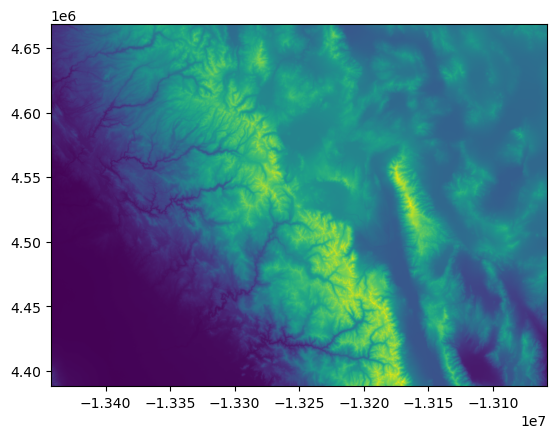

<Axes: >

In [10]:
# Quick default visualization using closest default settings

rasterio.plot.show(src)

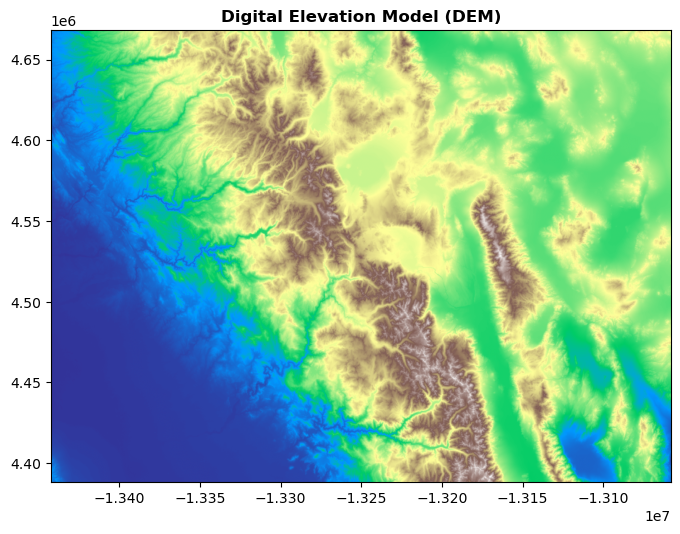

In [11]:
# Create a Matplotlib figure/axes so we can control size and style
fig, ax = plt.subplots(figsize=(8,8))
# Draw the DEM with a terrain colormap and a title on our axes
rasterio.plot.show(
    src,
    cmap="terrain",
    ax=ax,
    title="Digital Elevation Model (DEM)"
)
# Render the plot to the notebook/output
plt.show()


## Adding Colorbars

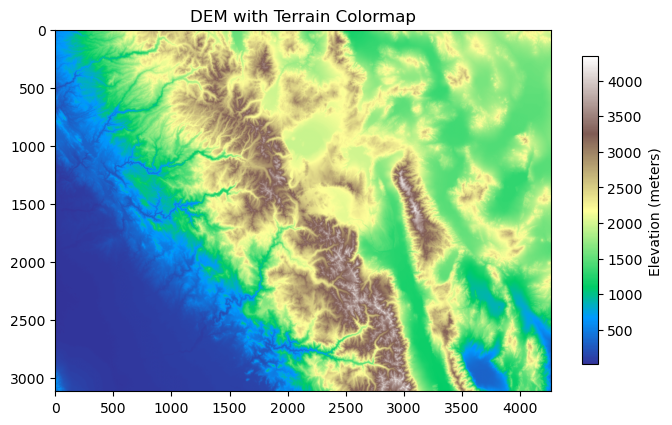

In [12]:
# Read the first (and only) band of the DEM into a NumPy array
elev_band = src.read(1)
# Start a square figure for consistent aspect
plt.figure(figsize=(8,8))
# Display the elevation band with the terrain palette
plt.imshow(elev_band, cmap="terrain")
# Add a colorbar to interpret elevation values (meters) with a smaller bar
plt.colorbar(label="Elevation (meters)", shrink=0.5)
# Title the plot for clarity
plt.title("DEM with Terrain Colormap")
# Show the finished plot
plt.show()

## Visualizing Multiple Bands


In [13]:
# URL for Landsat 9 surface reflectance raster with multiple spectral bands
raster_path = "https://github.com/opengeos/datasets/releases/download/raster/LC09_039035_20240708_90m.tif"
# Open the multispectral raster to access its bands
src = rasterio.open(raster_path)


In [14]:
# List the human-readable band descriptions (e.g., SR_B1, SR_B2, ...)
src.descriptions


('SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B6', 'SR_B7')

In [15]:
# Read specific bands into arrays: green=3, red=4, near-infrared=5
green_band = src.read(3)
red_band = src.read(4)
nir_band = src.read(5)

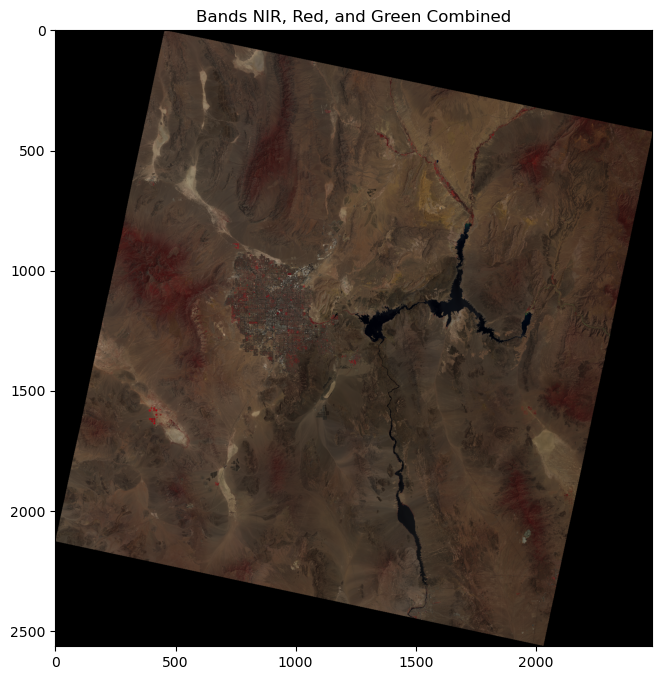

In [16]:
# Stack the bands into a single array for RGB-like visualization (NIR, Red, Green)
rgb = np.dstack((nir_band, red_band, green_band)).clip(0,1)
# Plot the stacked array
plt.figure(figsize=(8,8))
# Show the composite; values already clipped to 0-1 range
plt.imshow(rgb)
# Label the plot with the band combination used
plt.title("Bands NIR, Red, and Green Combined")
# Display the figure
plt.show()

## Overlaying Vector Data

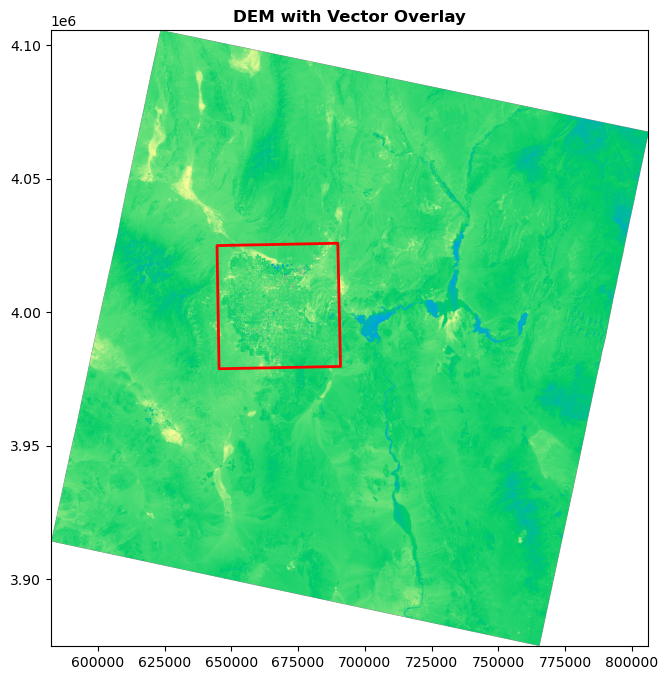

In [17]:
# Load raster data for the Las Vegas scene
raster_path = (
 "https://github.com/opengeos/datasets/releases/download/raster/LC09_039035_20240708_90m.tif"
)
# Open the Landsat scene so we can overlay vectors on top
src = rasterio.open(raster_path)
# Load vector boundary of Las Vegas in UTM coordinates
vector_path = (
 "https://github.com/opengeos/datasets/releases/download/places/las_vegas_bounds_utm.geojson"
)
# Read the GeoJSON into a GeoDataFrame
gdf = gpd.read_file(vector_path)
# Reproject vector to match raster CRS so overlay lines up
gdf = gdf.to_crs(src.crs)  # Ensure same CRS as raster
# Create the plot figure/axes with a consistent square aspect
fig, ax = plt.subplots(figsize=(8,8))
# Draw the raster with a terrain color ramp and title
rasterio.plot.show(src, cmap="terrain", ax=ax, title="DEM with Vector Overlay")
# Outline the vector boundary on top using a red stroke and no fill
gdf.plot(ax=ax, edgecolor="red", facecolor="none", linewidth=2)
# Render the combined plot
plt.show()


## Clipping Raster With Vector Layer

In [18]:
# Fiona reads vector geometries for masking
import fiona
# rasterio.mask applies a vector mask to trim raster pixels
import rasterio.mask
# Apply the mask to extract only the area within the vector bounds
with fiona.open(vector_path, "r") as f:
 # Collect polygon geometries from the features
 shapes = [feature["geometry"] for feature in f]
# Run mask operation cropping to shapes; returns clipped data and new transform
out_image, out_transform = rasterio.mask.mask(src, shapes, crop=True)
# Start with the original raster metadata as a template
out_meta = src.meta.copy()
# Update spatial metadata to match the clipped array dimensions and transform
out_meta.update(
 {
 "driver": "GTiff",
 "height": out_image.shape[1],
 "width": out_image.shape[2],
 "transform": out_transform,
 }
)
# Save the clipped raster to disk using the updated metadata
with rasterio.open("las_vegas_clipped.tif", "w", **out_meta) as dst:
 dst.write(out_image)

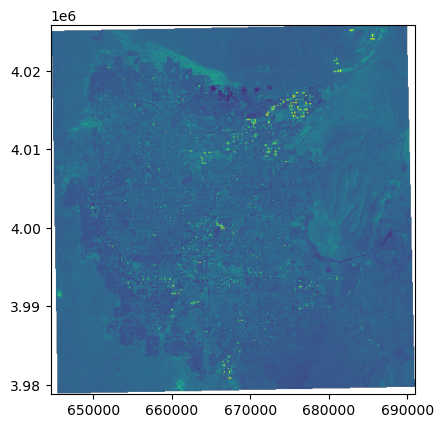

<Axes: >

In [19]:
# Open the newly clipped raster for visualization
lasveg = rasterio.open("las_vegas_clipped.tif")
# Display the clipped raster with Rasterio's default style
rasterio.plot.show(lasveg)

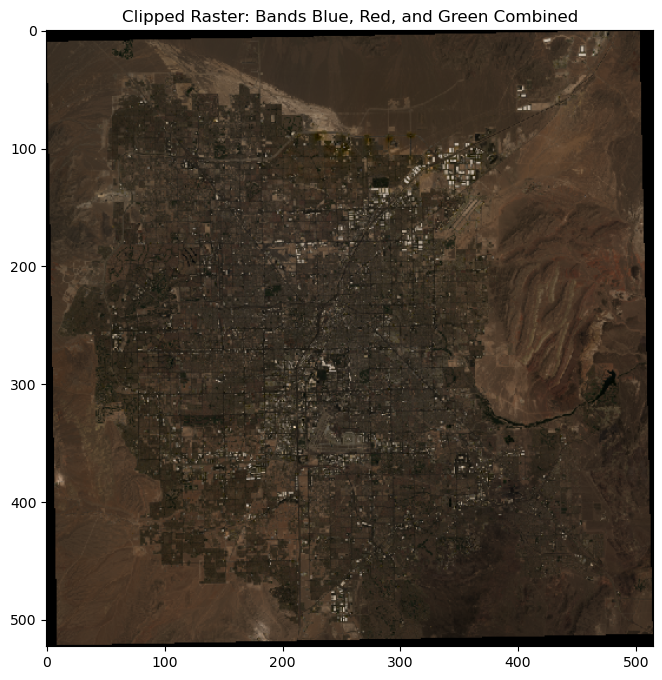

In [24]:
with rasterio.open("las_vegas_clipped.tif") as lasveg_rgb:
    blue_band = lasveg_rgb.read(2)
    red_band = lasveg_rgb.read(4)
    green_band = lasveg_rgb.read(3)

rgb = np.dstack((red_band, green_band, blue_band)).clip(0,1)

plt.figure(figsize=(8,8))
plt.imshow(rgb)
plt.title("Clipped Raster: Bands Blue, Red, and Green Combined")
plt.show()